In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/archive.zip" -d "/content/dataset"




Archive:  /content/drive/MyDrive/archive.zip
  inflating: /content/dataset/animals/cat/00000-4122619873.png  
  inflating: /content/dataset/animals/cat/00001-4122619874.png  
  inflating: /content/dataset/animals/cat/00002-4122619875.png  
  inflating: /content/dataset/animals/cat/00003-4122619876.png  
  inflating: /content/dataset/animals/cat/00004-4122619877.png  
  inflating: /content/dataset/animals/cat/00005-4122619878.png  
  inflating: /content/dataset/animals/cat/00006-4122619879.png  
  inflating: /content/dataset/animals/cat/00007-4122619880.png  
  inflating: /content/dataset/animals/cat/00008-4122619881.png  
  inflating: /content/dataset/animals/cat/00009-4122619882.png  
  inflating: /content/dataset/animals/cat/00010-4122619883.png  
  inflating: /content/dataset/animals/cat/00011-4122619884.png  
  inflating: /content/dataset/animals/cat/00012-4122619885.png  
  inflating: /content/dataset/animals/cat/00013-4122619886.png  
  inflating: /content/dataset/animals/cat/000

In [ ]:

zip_path = "/content/drive/MyDrive/archive.zip"


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")


os.listdir("/content/dataset")


['animals']

In [ ]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
train_dir = '/content/dataset/animals'

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
train_dir = '/content/dataset/animals'

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [ ]:
# Build the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary output
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 527ms/step - accuracy: 0.5381 - loss: 0.9188 - val_accuracy: 0.6500 - val_loss: 0.6126
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 458ms/step - accuracy: 0.7524 - loss: 0.5081 - val_accuracy: 0.8400 - val_loss: 0.4089
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.9054 - loss: 0.2636 - val_accuracy: 0.9200 - val_loss: 0.2540
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 426ms/step - accuracy: 0.9561 - loss: 0.1700 - val_accuracy: 0.9250 - val_loss: 0.2162
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step - accuracy: 0.9831 - loss: 0.0851 - val_accuracy: 0.9350 - val_loss: 0.1405
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.9901 - loss: 0.0489 - val_accuracy: 0.9550 - val_loss: 0.1108
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.9989 - loss: 0.0232 - val_accuracy: 0.9550 - val_loss: 0.0928
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 455ms/step - accuracy: 0.9959 - loss: 0.0223 - val_accu

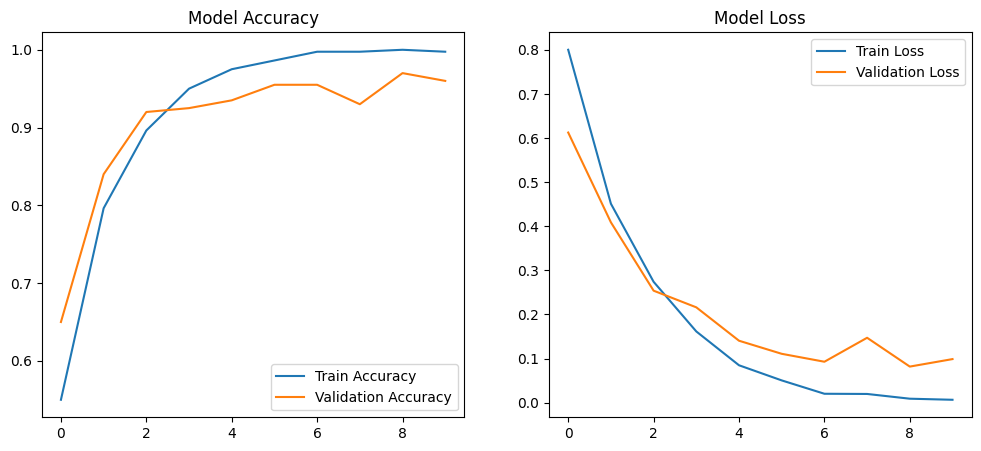

In [ ]:
# Plot Accuracy & Loss
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 358ms/step - accuracy: 0.9602 - loss: 0.0724
Validation Accuracy: 96.00%
Validation Loss: 0.0988


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 397ms/step


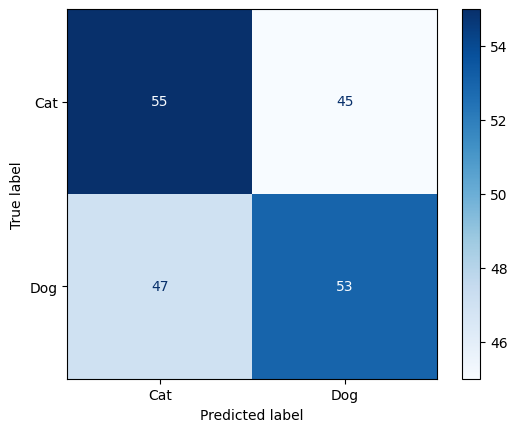

In [ ]:

val_generator.reset()
y_true = val_generator.classes
y_pred = (model.predict(val_generator) > 0.5).astype("int32")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np


uploaded = files.upload()


Saving Cat.jpg to Cat.jpg


In [ ]:

img_path = list(uploaded.keys())[0]


test_img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(test_img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0


In [ ]:

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("🐶 The model predicts: **Cat**")
else:
    print("🐱 The model predicts: **Dog**")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
🐶 The model predicts: **Cat**


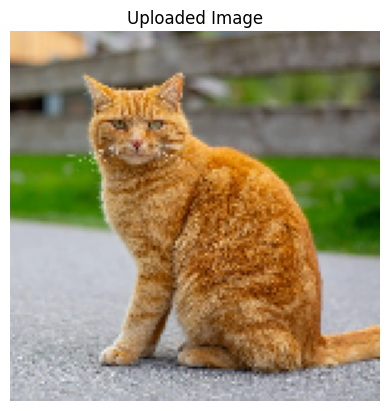

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(test_img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/content/dataset",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    "/content/dataset",
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


Found 1000 images belonging to 1 classes.
Found 1000 images belonging to 1 classes.
